# Azure App Service acquisition and observed usage

**Scope.** Descriptive account acquisition and observed account-day activity for the 977-account cohort created Feb 1–27, 2022. This notebook verifies the source contract, rebuilds all tables and QA-approved figures from repository inputs, then reports results. Run from the repository root; see the project README.

The repository-level source README says account creation runs through Feb 28, 2022, but `Case_AccountCreation.csv` contains records only through Feb 27 (27 dates; 977 accounts). This analysis follows the verified CSV, not the broader README statement. Source files are not changed.

## Definitions and interpretation

- **Acquisition composition/timing:** counts and shares of the 977-account cohort. Daily share denominator is 977. Weekly bins start Sunday; Feb 1–5 and Feb 27 are partial observed weeks.
- **Calendar-date observed coverage:** for each date Feb 1–Apr 30, numerator = distinct cohort accounts with an observed usage row on the date; denominator = cohort accounts created on or before that date. The denominator rises through Feb 27 and is 977 thereafter. Pooled calendar coverage is total observed account-day rows divided by total eligible account-dates in this calendar window.
- **Equal account-age observed coverage:** age 0 is the creation date (inclusive). For each age day 0–62, numerator = accounts with an observed usage row at that age; denominator = all 977 cohort accounts. This is a complete 63-day window for every account.
- **Per-account window summary:** distinct dates with an observed row during ages 0–62; observed-day rate = count / 63.

An absent account-day means only that no row was observed in this extract; it is not verified inactivity. Calendar-date coverage reflects both usage records and the changing eligible population; later-created accounts have less possible calendar follow-up before the Apr 30 extract end. The fixed age window makes follow-up length comparable only for days 0–62. These are descriptive summaries, not causal/inferential estimates, and do not define retention or churn.

In [1]:
from collections import Counter
from datetime import date, timedelta
from pathlib import Path
import os
import runpy

import pandas as pd
from IPython.display import Image, display

ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "Case_AccountData.csv").is_file()), None)
assert ROOT is not None, "Execute this notebook from the repository root."
PROJECT = ROOT / "projects" / "20260929_rbouch85_app-service-analysis"
TABLES = PROJECT / "outputs" / "tables"
FIGURES = PROJECT / "outputs" / "figures"

assert (ROOT / "Case_AccountData.csv").is_file(), "Execute this notebook from the repository root."
accounts = pd.read_csv(ROOT / "Case_AccountData.csv", dtype=str)
creation = pd.read_csv(ROOT / "Case_AccountCreation.csv", dtype=str)
usage = pd.read_csv(ROOT / "Case_UsageData.csv", dtype=str)

# Validate schemas, source grain, joins, dates, and completeness before reporting metrics.
assert set(accounts.columns) == {"AccountID", "CustomerType", "DevLanguage"}
assert set(creation.columns) == {"AccountID", "AccountCreatedDay", "AccountCreatedDay_Key", "AccountCreatedWeek", "AccountCreatedWeek_Key"}
assert set(usage.columns) == {"AccountID", "UsageDate", "UsageDate_Key"}
assert len(accounts) == len(creation) == 977
assert accounts["AccountID"].is_unique and creation["AccountID"].is_unique
assert set(accounts["AccountID"]) == set(creation["AccountID"])
assert not accounts.isna().any().any() and not creation.isna().any().any() and not usage.isna().any().any()
assert (accounts.apply(lambda col: col.str.strip().ne("")).all().all())
assert (creation.apply(lambda col: col.str.strip().ne("")).all().all())
assert (usage.apply(lambda col: col.str.strip().ne("")).all().all())
creation["created_date"] = pd.to_datetime(creation["AccountCreatedDay"], utc=True).dt.tz_convert(None).dt.normalize()
usage["usage_date"] = pd.to_datetime(usage["UsageDate"], utc=True).dt.tz_convert(None).dt.normalize()
assert creation["created_date"].min() == pd.Timestamp("2022-02-01")
assert creation["created_date"].max() == pd.Timestamp("2022-02-27")
assert creation["created_date"].nunique() == 27
assert (creation["AccountCreatedDay_Key"] == creation["created_date"].dt.strftime("%Y%m%d")).all()
assert (usage["UsageDate_Key"] == usage["usage_date"].dt.strftime("%Y%m%d")).all()
assert len(usage) == 44_352
assert not usage.duplicated(["AccountID", "usage_date"]).any()
assert set(usage["AccountID"]) == set(creation["AccountID"])
created_by_id = creation.set_index("AccountID")["created_date"]
assert (usage["usage_date"].to_numpy() >= usage["AccountID"].map(created_by_id).to_numpy()).all()
expected_usage_dates = pd.date_range("2022-02-01", "2022-04-30", freq="D")
assert usage["usage_date"].nunique() == 89
assert set(usage["usage_date"]) == set(expected_usage_dates)
assert usage["usage_date"].min() == pd.Timestamp("2022-02-01")
assert usage["usage_date"].max() == pd.Timestamp("2022-04-30")
assert "unknown" in set(accounts["DevLanguage"])
print("Source assertions passed: 977 matched accounts; 44,352 unique account-days; 89 consecutive usage dates.")

Source assertions passed: 977 matched accounts; 44,352 unique account-days; 89 consecutive usage dates.


In [2]:
# Rebuild every output in the agreed order. The figure builder's relative path is
# intentionally run with the project directory as the working directory.
runpy.run_path(str(PROJECT / "outputs" / "tables" / "build_acquisition_tables.py"), run_name="__main__")
runpy.run_path(str(PROJECT / "outputs" / "tables" / "build_usage_tables.py"), run_name="__main__")
_previous_cwd = Path.cwd()
os.chdir(PROJECT)
try:
    runpy.run_path('outputs/figures/build_figures.py', run_name='__main__')
finally:
    os.chdir(_previous_cwd)
print("Acquisition and usage tables rebuilt; all three approved figures regenerated.")

C:\Python\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 10 x 5.2 in image.
C:\Python\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\rybouc\.copilot\repos\InterviewCase_Public\projects\20260929_rbouch85_app-service-analysis\outputs\figures\weekly_acquisition.png


C:\Python\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 5.4 in image.
C:\Python\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\rybouc\.copilot\repos\InterviewCase_Public\projects\20260929_rbouch85_app-service-analysis\outputs\figures\acquisition_composition.png


C:\Python\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 5.6 in image.
C:\Python\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\rybouc\.copilot\repos\InterviewCase_Public\projects\20260929_rbouch85_app-service-analysis\outputs\figures\observed_account_day_coverage.png


Acquisition and usage tables rebuilt; all three approved figures regenerated.


In [3]:
# Load the persisted tables that are the documented metric and visualization inputs.
acq_daily = pd.read_csv(TABLES / "acquisition_daily.csv")
acq_weekly = pd.read_csv(TABLES / "acquisition_weekly_sunday_start.csv")
customer_mix = pd.read_csv(TABLES / "acquisition_composition_customer_type.csv")
language_mix = pd.read_csv(TABLES / "acquisition_composition_dev_language.csv")
calendar = pd.read_csv(TABLES / "daily_observed_coverage.csv")
age = pd.read_csv(TABLES / "age_day_observed_coverage.csv")
per_account = pd.read_csv(TABLES / "per_account_age_0_62_observed_days.csv")

assert len(acq_daily) == 27 and len(acq_weekly) == 5
assert len(customer_mix) == 3 and len(language_mix) == 6
assert len(calendar) == 89 and len(age) == 63 and len(per_account) == 977
assert customer_mix["account_count"].sum() == len(accounts)
assert language_mix["account_count"].sum() == len(accounts)
assert acq_daily["account_count"].sum() == len(accounts)
assert acq_weekly["account_count"].sum() == len(accounts)
assert calendar["observed_account_count"].sum() == len(usage)
assert calendar["eligible_account_count"].sum() == 75_386
assert age["eligible_account_count"].eq(977).all()
assert age["age_day"].tolist() == list(range(63))
assert per_account["AccountID"].is_unique
assert per_account["distinct_observed_days_age_0_62"].between(0, 63).all()
assert abs(calendar["observed_coverage_rate"].iloc[-1] - 407 / 977) < 1e-8
assert abs(age.loc[age["age_day"] == 30, "observed_usage_account_fraction"].iloc[0] - 591 / 977) < 1e-8

pooled_calendar_rate = calendar["observed_account_count"].sum() / calendar["eligible_account_count"].sum()
mean_age_coverage = age["observed_usage_account_fraction"].mean()
observed_days = per_account["distinct_observed_days_age_0_62"]
print(f"Cohort accounts: {len(accounts):,}; usage account-day rows: {len(usage):,}.")
print(f"Calendar window: {calendar['date'].min()} to {calendar['date'].max()}; observed/eligible account-days = {calendar['observed_account_count'].sum():,}/{calendar['eligible_account_count'].sum():,} ({pooled_calendar_rate:.2%} pooled).")
print(f"Calendar daily coverage: {calendar.iloc[0]['observed_account_count']}/{calendar.iloc[0]['eligible_account_count']} on {calendar.iloc[0]['date']}; {calendar.iloc[-1]['observed_account_count']}/{calendar.iloc[-1]['eligible_account_count']} on {calendar.iloc[-1]['date']}.")
print(f"Account age 0-62: eligible accounts/day = 977; mean age-day observed coverage = {mean_age_coverage:.2%}; day 0 = {int(age.iloc[0]['accounts_with_observed_usage'])}/977; day 30 = {int(age.loc[age.age_day == 30, 'accounts_with_observed_usage'].iloc[0])}/977; day 62 = {int(age.iloc[-1]['accounts_with_observed_usage'])}/977.")
print(f"Per-account distinct observed days (63-day window): median {observed_days.median():.0f}, mean {observed_days.mean():.2f}, range {observed_days.min()}-{observed_days.max()}.")
display(customer_mix.assign(share_pct=(customer_mix.share_of_cohort * 100).round(2)))
display(language_mix.assign(share_pct=(language_mix.share_of_cohort * 100).round(2)))
display(acq_weekly)

Cohort accounts: 977; usage account-day rows: 44,352.
Calendar window: 2022-02-01 to 2022-04-30; observed/eligible account-days = 44,352/75,386 (58.83% pooled).
Calendar daily coverage: 28/28 on 2022-02-01; 407/977 on 2022-04-30.
Account age 0-62: eligible accounts/day = 977; mean age-day observed coverage = 62.58%; day 0 = 977/977; day 30 = 591/977; day 62 = 421/977.
Per-account distinct observed days (63-day window): median 35, mean 39.42, range 1-63.


,category,account_count,cohort_account_denominator,share_of_cohort,share_pct
0,Credit_Program,110,977,0.112590,11.26
1,Enterprise,242,977,0.247697,24.77
2,SMB,625,977,0.639713,63.97


,category,account_count,cohort_account_denominator,share_of_cohort,share_pct
0,dotnet,266,977,0.272262,27.23
1,java,41,977,0.041965,4.20
2,node,119,977,0.121801,12.18
3,php,84,977,0.085977,8.60
4,python,105,977,0.107472,10.75
5,unknown,362,977,0.370522,37.05


,sunday_start_week,calendar_week_end,observed_cohort_start,observed_cohort_end,partial_week,account_count,cohort_account_denominator,share_of_cohort
0,2022-01-30,2022-02-05,2022-02-01,2022-02-05,True,174,977,0.178096
1,2022-02-06,2022-02-12,2022-02-06,2022-02-12,False,324,977,0.331627
2,2022-02-13,2022-02-19,2022-02-13,2022-02-19,False,239,977,0.244626
3,2022-02-20,2022-02-26,2022-02-20,2022-02-26,False,234,977,0.239509
4,2022-02-27,2022-03-05,2022-02-27,2022-02-27,True,6,977,0.006141


## Findings and product-team validation

1. **Composition:** SMB is the largest reported segment (625/977, 63.97%), followed by Enterprise (242/977, 24.77%) and Credit_Program (110/977, 11.26%). `unknown` is a real language category for 362 accounts (37.05%), not a null; dotnet is 266 (27.23%), node 119 (12.18%), python 105 (10.75%), php 84 (8.60%), and java 41 (4.20%).
2. **Acquisition timing:** daily creation peaked at 87 accounts on Feb 7. Sunday-start bucket counts were 174, 324, 239, 234, and 6; the first and last observed buckets are partial and should not be compared as complete weeks.
3. **Coverage changes by calendar and age:** 44,352 observed account-days comprise 58.83% of 75,386 eligible calendar account-days. Calendar coverage fell from 28/28 on Feb 1 to 407/977 on Apr 30, but the denominator changes through Feb 27, and the end-of-extract date limits later cohorts' possible follow-up. In the equal-age window, average daily coverage was 62.58%; observed usage was present for 977/977 accounts at age day 0, 591/977 at day 30, and 421/977 at day 62. Per-account distinct observed days were median 35, mean 39.42, range 1–63 of 63.
4. **Interpretation boundary:** these counts concern observed records only. An absent daily record is not verified non-use. Neither calendar coverage nor age-day coverage is labeled retention, and the patterns do not establish cause or future behavior.

### Questions for the product team

- What does one row in `Case_UsageData` mean operationally (any product use, a qualifying session, or a particular event), and are ingestion gaps or delayed records possible?
- Why are 37% of development-language values `unknown`: not collected, unsupported, withheld, or unavailable at extraction? Can the field be validated against product telemetry?
- Do the February creation dates represent production account creation consistently, and are there excluded accounts, backfills, or Feb 28 records omitted from this extract?
- Which product-defined activation or retention event, and what comparable follow-up horizon (for example, fixed 30/60/90 days), should be used in a later analysis? Can the product team provide event-level records and mature cohorts for that estimand?

## QA-approved figures

The following images are regenerated from the persisted summary tables by Viz-dude's builder. They are shown here without further transformation.

weekly_acquisition.png


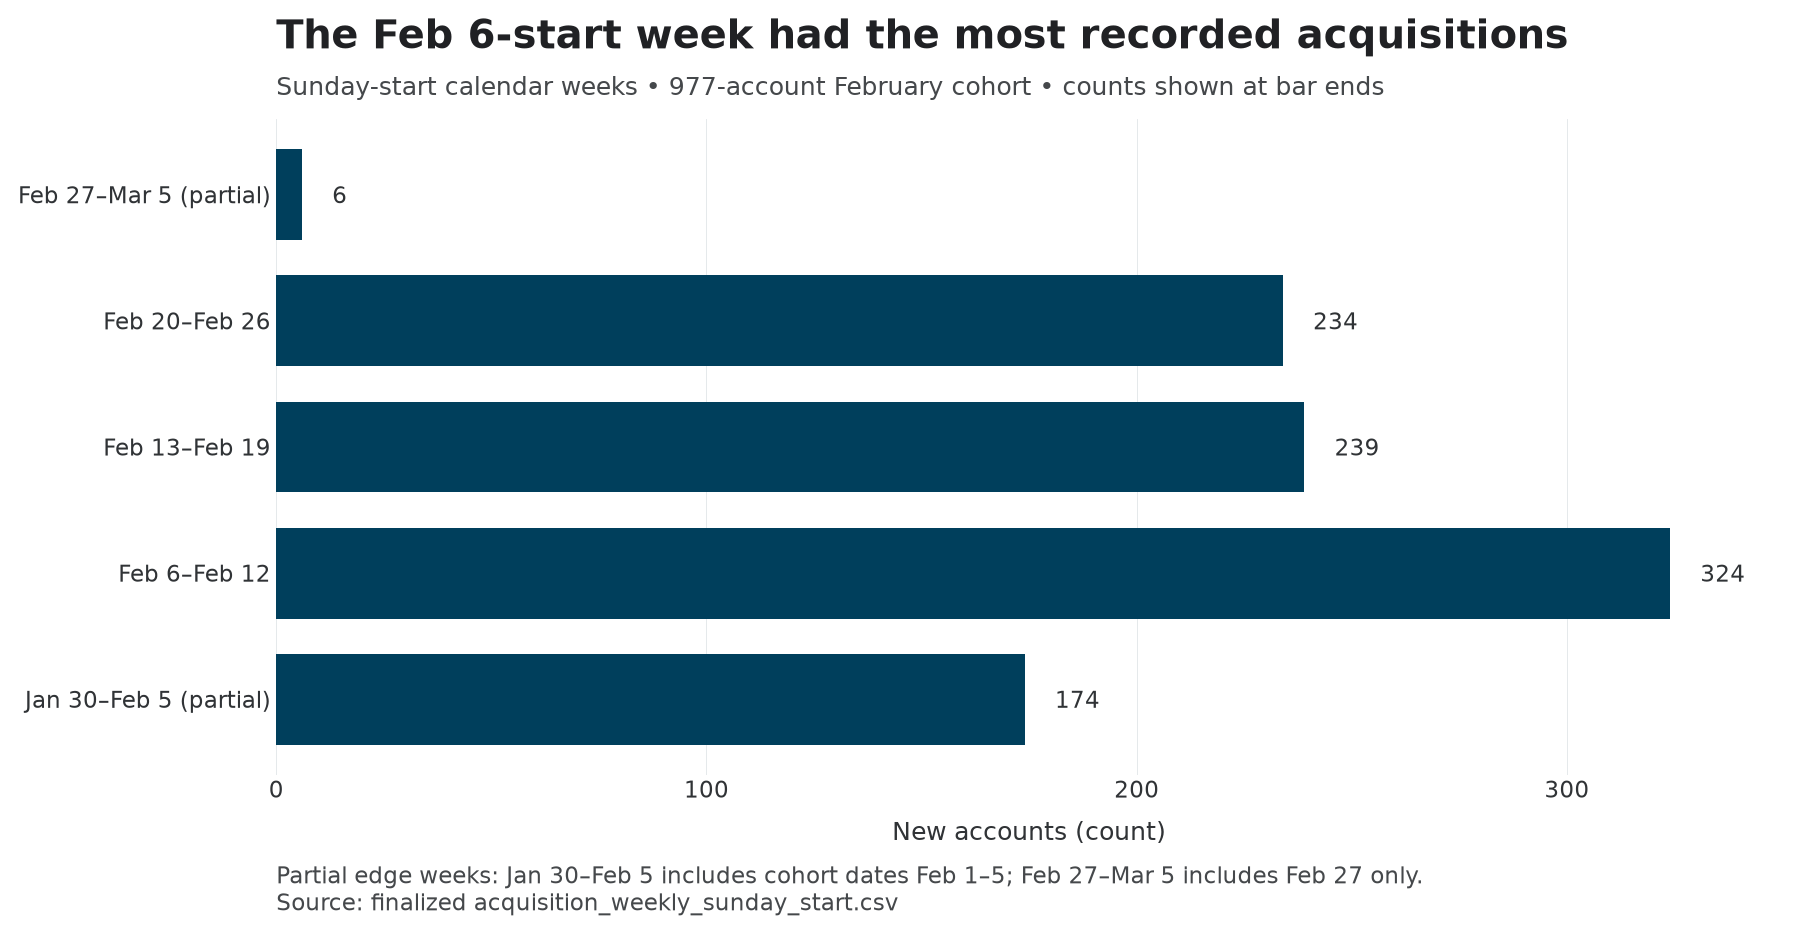

acquisition_composition.png


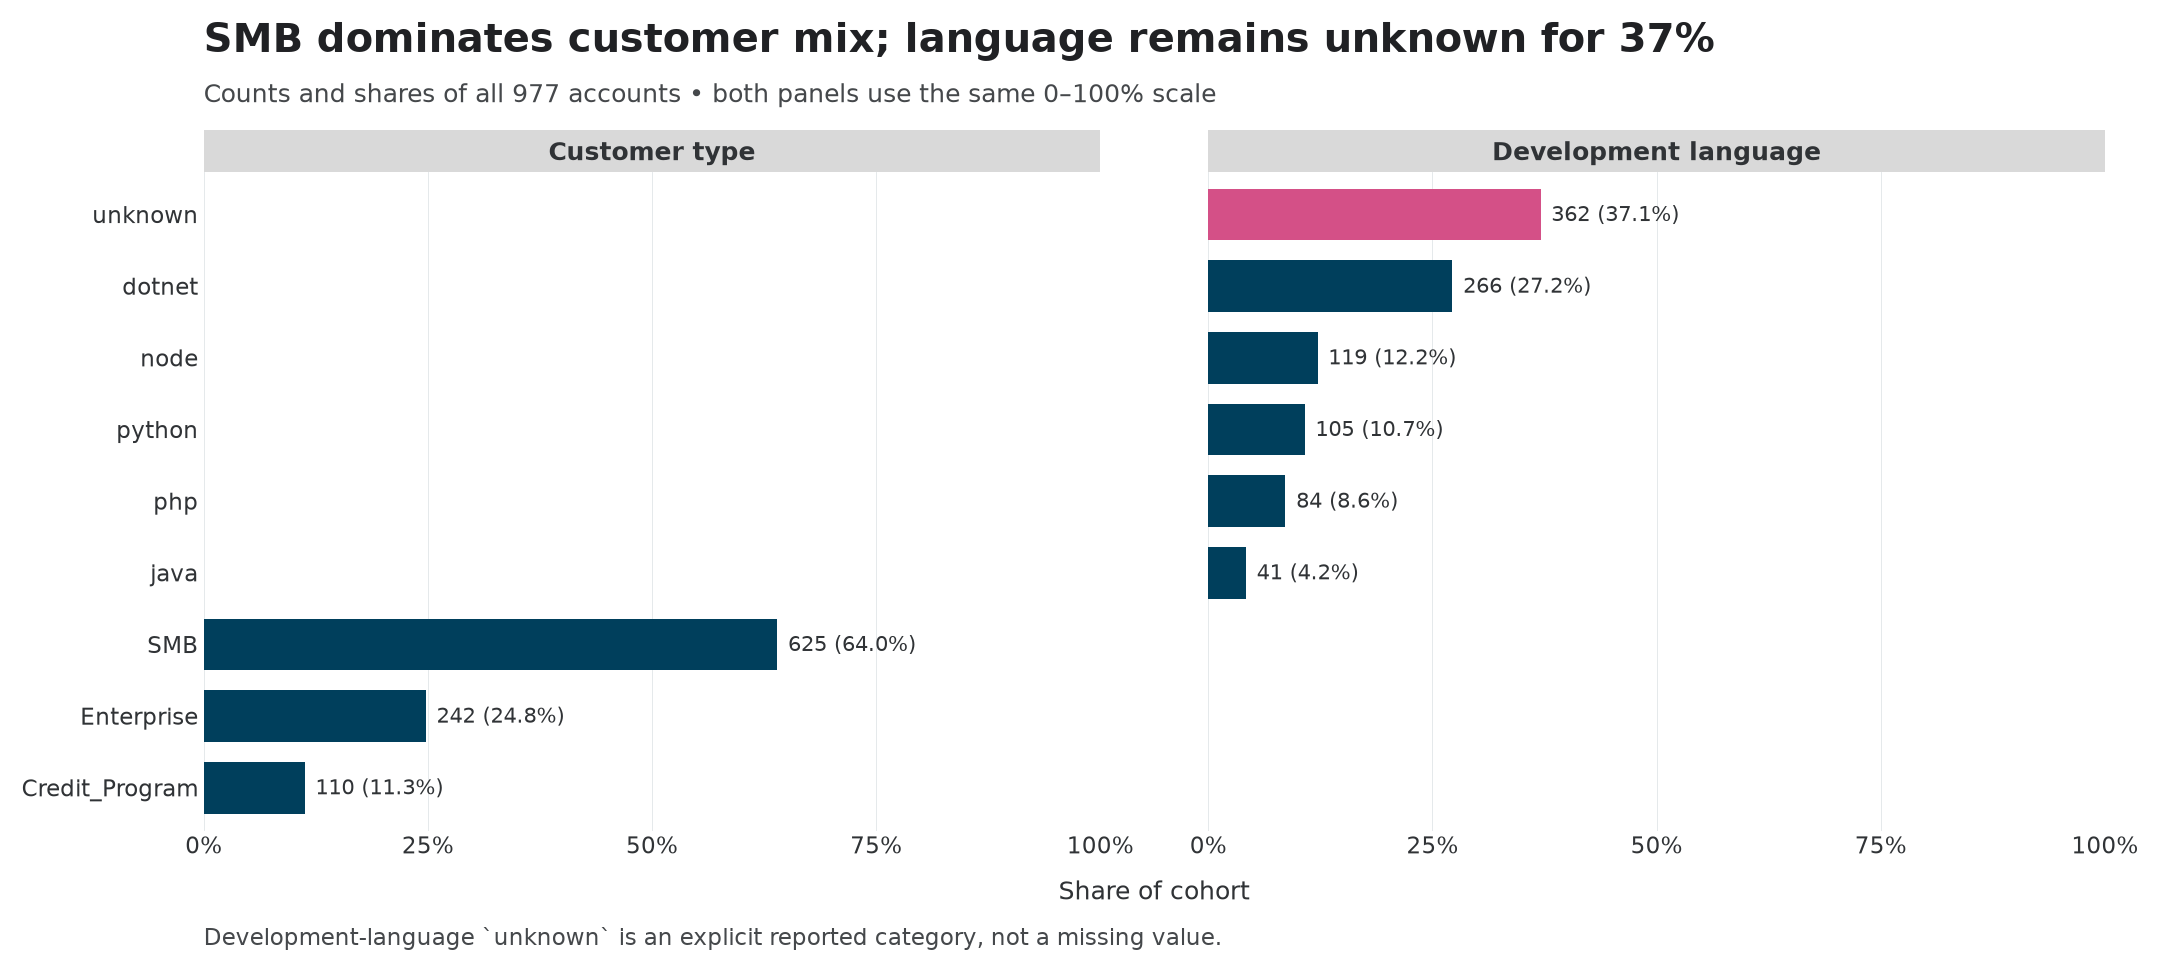

observed_account_day_coverage.png


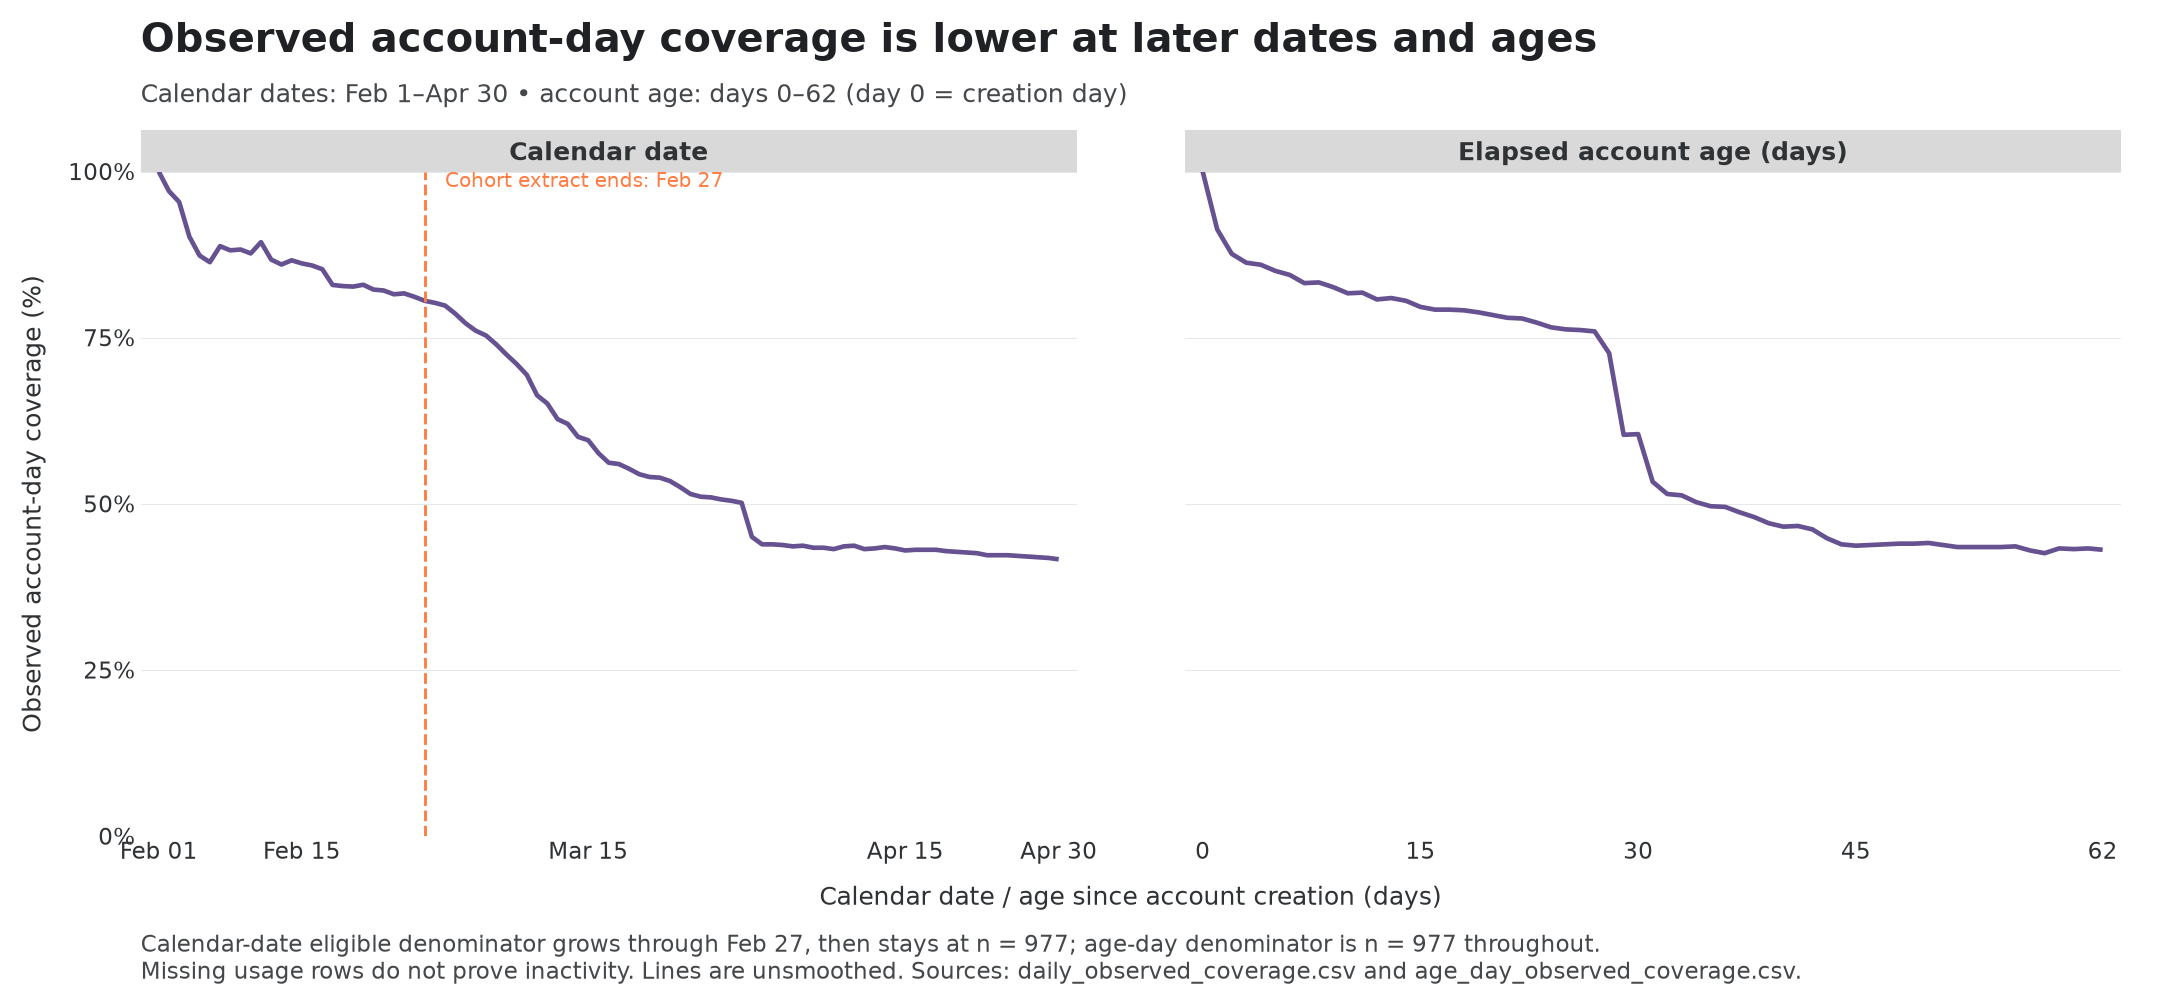

In [4]:
for filename in ["weekly_acquisition.png", "acquisition_composition.png", "observed_account_day_coverage.png"]:
    image_path = FIGURES / filename
    assert image_path.is_file(), f"Expected builder output missing: {image_path}"
    print(filename)
    display(Image(filename=str(image_path)))

## Reproduction and output paths

From the repository root, run:

```powershell
jupyter nbconvert --to notebook --execute --inplace projects\20260929_rbouch85_app-service-analysis\analysis.ipynb
```

Tables are in `projects/20260929_rbouch85_app-service-analysis/outputs/tables/`: `acquisition_daily.csv`, `acquisition_weekly_sunday_start.csv`, `acquisition_composition_customer_type.csv`, `acquisition_composition_dev_language.csv`, `daily_observed_coverage.csv`, `age_day_observed_coverage.csv`, and `per_account_age_0_62_observed_days.csv`. Rebuild scripts: `outputs/tables/build_acquisition_tables.py` and `outputs/tables/build_usage_tables.py`. Figures are `outputs/figures/weekly_acquisition.png`, `acquisition_composition.png`, and `observed_account_day_coverage.png`, generated by `outputs/figures/build_figures.py`.